In [10]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import libpysal
from esda.moran import Moran_Local_BV, Moran_BV
from pyprojroot import here
from shapely.geometry import box

In [17]:
ROOT        = here()
BUS_PATH = ROOT/ "data" / "Bus_Routes.geojson"
BUS_OUTPUT_PATH = ROOT / "data" / "bus_routes_hero.geojson"

In [7]:
buses = gpd.read_file(BUS_PATH)

In [9]:
print(buses.columns.tolist())

['DIRECTION', 'RTE_RUN', 'RTE_SORT', 'ROUTE', 'STATUS', 'RUN_NO', 'RUN_TYPE', 'RUN_LENGTH', 'DATE_UPDATED', 'AUTHORITIES', 'OBJECTID', 'INTEL_SPEED_ASSIST', 'ISA_TYPE', 'Shape__Length', 'geometry']


In [13]:
print(buses.columns.tolist())
print(f"Total features: {len(buses)}")

# Keep one direction per route
buses_deduped = buses.drop_duplicates(subset='ROUTE')

inner_london = box(-0.5, 51.35, 0.2, 51.65)
buses_inner = buses_deduped[buses_deduped.intersects(inner_london)]

print(f"Total routes: {len(buses)}")
print(f"Filtered routes: {len(buses_inner)}")

['DIRECTION', 'RTE_RUN', 'RTE_SORT', 'ROUTE', 'STATUS', 'RUN_NO', 'RUN_TYPE', 'RUN_LENGTH', 'DATE_UPDATED', 'AUTHORITIES', 'OBJECTID', 'INTEL_SPEED_ASSIST', 'ISA_TYPE', 'Shape__Length', 'geometry']
Total features: 1708
Total routes: 1708
Filtered routes: 784


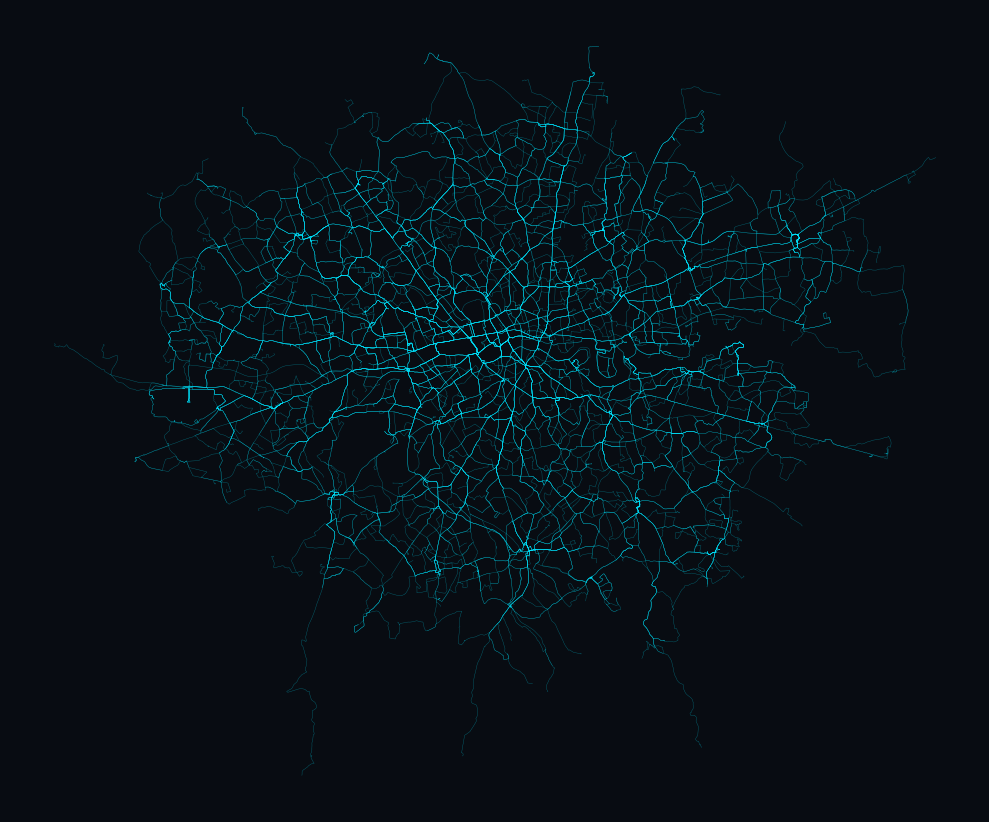

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10), facecolor='#080c12')
buses_inner.plot(ax=ax, color='#00e5ff', linewidth=0.3, alpha=0.4)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [18]:
# Export for tippecanoe
buses_inner.to_crs('EPSG:4326')[['ROUTE', 'geometry']].to_file(BUS_OUTPUT_PATH, driver="GeoJSON")

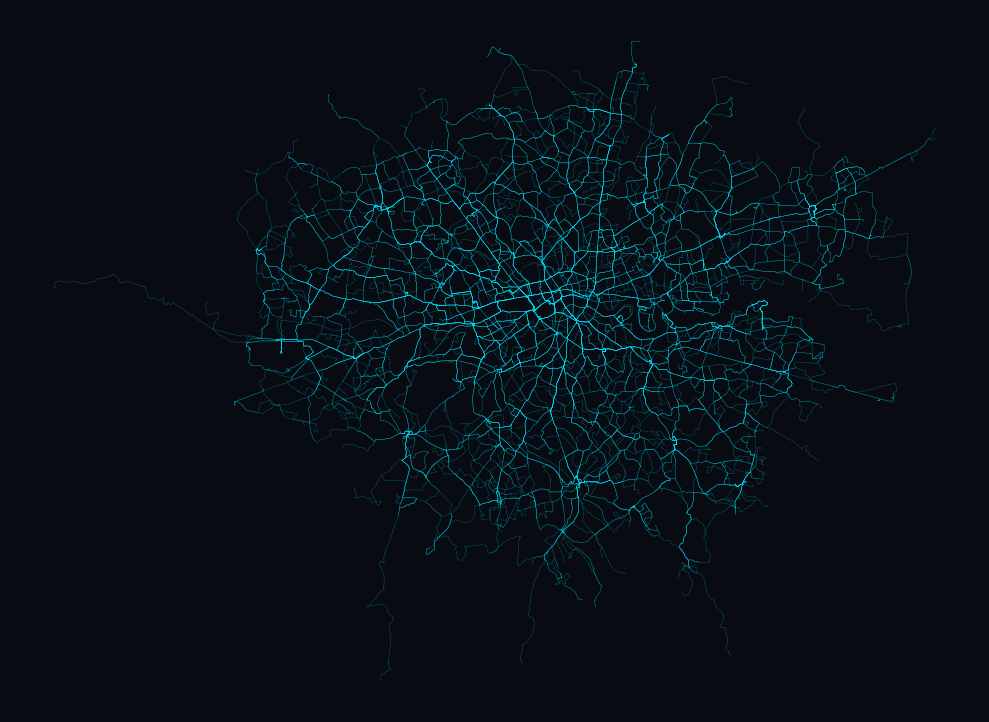

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10), facecolor='#080c12')
buses_deduped.plot(ax=ax, color='#00e5ff', linewidth=0.3, alpha=0.4)
ax.set_axis_off()
plt.tight_layout()
plt.show()